In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

In [4]:
adata_whole = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/re_annot.h5ad')

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Cell proportions
#### Sankey plot for 4 subsets where the width of the flow shows how much of that category's population maps to the different cell types

In [6]:
df = adata_whole.obs.groupby(['sex', 're_annot']).size().reset_index(name='count')

# rename sex_condition to group
# df = df.rename(columns={'sex_condition': 'group'})
df = df.rename(columns={'sex': 'group'})
# rename re_annot to cell_type
df = df.rename(columns={'re_annot': 'cell_type'})
display(df.head())

/tmp/ipykernel_3920243/3801322805.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_whole.obs.groupby(['sex', 're_annot']).size().reset_index(name='count')


,group,cell_type,count
0,F,Fast IIB,19339
1,F,Fast IIX,12505
2,F,Fast IIA,1906
3,F,EC,1468
4,F,FAPs,1119


/tmp/ipykernel_3920243/2714747378.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_whole.obs.groupby([LEFT_COL, RIGHT_COL]).size().reset_index(name='count')
/tmp/ipykernel_3920243/2714747378.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = df.groupby(LEFT_COL)['count'].transform('sum')
/tmp/ipykernel_3920243/2714747378.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  left_totals  = df.grou

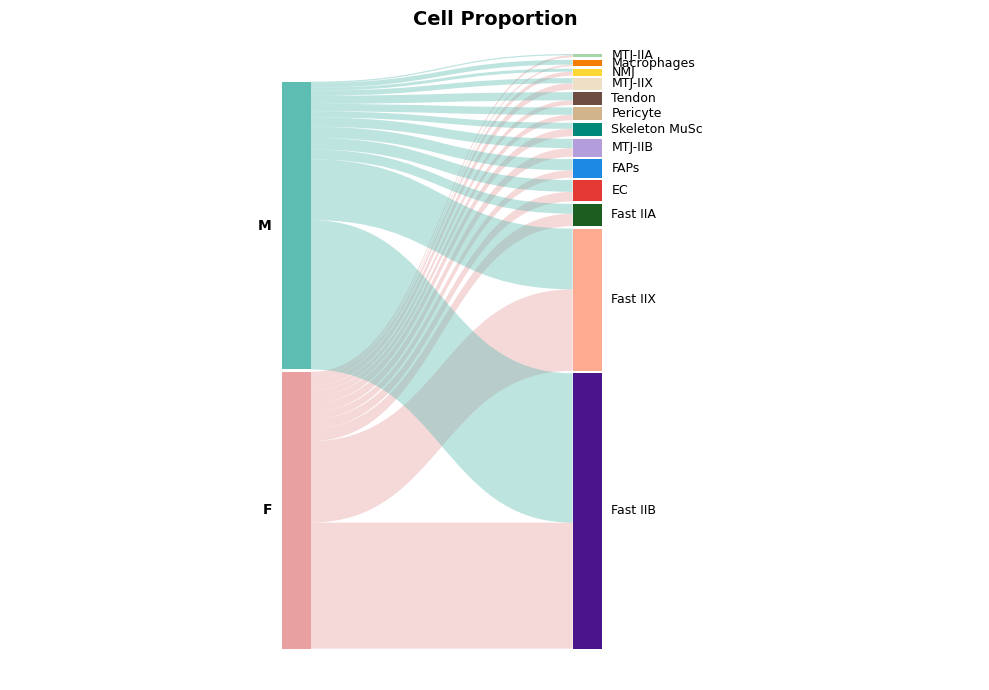

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patches as patches
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
LEFT_COL   = 'sex'
RIGHT_COL  = 're_annot'
LEFT_ORDER = ['F', 'M']

COLOR_MAP = {
    'F': '#e8a0a0',
    'M': '#5dbdb2',
}

# scanpy cell type colors — auto-pulled or define manually
cell_type_colors = dict(zip(
    adata_whole.obs[RIGHT_COL].cat.categories,
    adata_whole.uns.get(f'{RIGHT_COL}_colors', 
        plt.cm.tab20.colors[:len(adata_whole.obs[RIGHT_COL].cat.categories)])
))

# ── DATA ────────────────────────────────────────────────────────────────────
df = adata_whole.obs.groupby([LEFT_COL, RIGHT_COL]).size().reset_index(name='count')

left_groups  = LEFT_ORDER
right_groups = adata_whole.obs[RIGHT_COL].cat.categories.tolist()

# Normalize counts within each left group (proportions)
totals = df.groupby(LEFT_COL)['count'].transform('sum')
df['prop'] = df['count'] / totals

# ── LAYOUT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

BAR_W  = 0.03
GAP    = 0.008
X_LEFT = 0.28   # wider left margin for labels
X_RIGHT= 0.58   # closer to left bar
ALPHA  = 0.4

def calc_positions(groups, counts_dict, x_pos, bar_w):
    """Return {group: (y_bottom, y_top)} for stacked bars."""
    total = sum(counts_dict[g] for g in groups)
    positions = {}
    y = 0.05
    for g in groups:
        h = (counts_dict[g] / total) * 0.9
        positions[g] = (y, y + h)
        y += h + GAP * 0.5
    return positions

# Totals for sizing
left_totals  = df.groupby(LEFT_COL)['count'].sum().to_dict()
right_totals = df.groupby(RIGHT_COL)['count'].sum().to_dict()

left_pos  = calc_positions(left_groups,  left_totals,  X_LEFT,  BAR_W)
right_pos = calc_positions(right_groups, right_totals, X_RIGHT, BAR_W)

# ── DRAW FLOWS ──────────────────────────────────────────────────────────────
# Track current fill position for each bar
left_fill  = {g: left_pos[g][0]  for g in left_groups}
right_fill = {g: right_pos[g][0] for g in right_groups}

left_total_sum = sum(left_totals.values())

for _, row in df.sort_values([LEFT_COL, RIGHT_COL]).iterrows():
    lg, rg, cnt = row[LEFT_COL], row[RIGHT_COL], row['count']

    l_total = left_totals[lg]
    r_total = right_totals[rg]
    l_span  = (left_pos[lg][1] - left_pos[lg][0])
    r_span  = (right_pos[rg][1] - right_pos[rg][0])

    lh = (cnt / l_total) * l_span
    rh = (cnt / r_total) * r_span

    ly0 = left_fill[lg]
    ry0 = right_fill[rg]
    ly1 = ly0 + lh
    ry1 = ry0 + rh

    left_fill[lg]  += lh
    right_fill[rg] += rh

    # Bezier curve path
    verts = [
        (X_LEFT + BAR_W, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry0),
        (X_RIGHT, ry0),
        (X_RIGHT, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly1),
        (X_LEFT + BAR_W, ly1),
        (X_LEFT + BAR_W, ly0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    path  = Path(verts, codes)
    patch = patches.PathPatch(
        path,
        facecolor=COLOR_MAP[lg],
        edgecolor='none',
        alpha=ALPHA,
        zorder=1
    )
    ax.add_patch(patch)

# ── DRAW BARS ────────────────────────────────────────────────────────────────
for g in left_groups:
    y0, y1 = left_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_LEFT, y0), BAR_W, y1 - y0,
        color=COLOR_MAP[g], zorder=2, linewidth=0
    ))
    ax.text(X_LEFT - 0.01, (y0 + y1) / 2, g,
            ha='right', va='center', fontsize=10, fontweight='bold')

for g in right_groups:
    y0, y1 = right_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_RIGHT, y0), BAR_W, y1 - y0,
        color=cell_type_colors.get(g, '#aaaaaa'), zorder=2, linewidth=0
    ))
    ax.text(X_RIGHT + BAR_W + 0.01, (y0 + y1) / 2, g,
            ha='left', va='center', fontsize=9)

plt.title('Cell Proportion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{figures_dir}/sankey_M_F_to_cell_type.svg', bbox_inches='tight', dpi=300)
plt.show()

### Quantified WT and KO differences in proportions

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


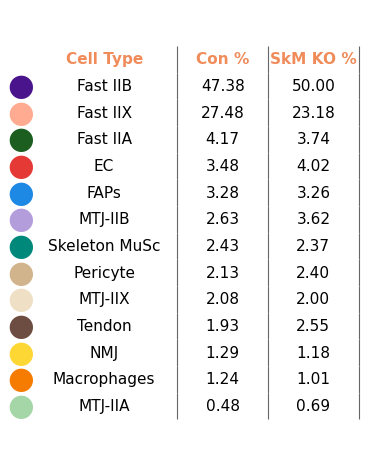

In [14]:
adata_re = adata_whole.copy()

# Pull palette from uns
re_annot_palette = dict(zip(
    adata_re.obs["re_annot"].cat.categories,
    adata_re.uns.get(
        "re_annot_colors",
        plt.cm.tab20.colors[:len(adata_re.obs["re_annot"].cat.categories)],
    ),
))

comp = (
    pd.crosstab(adata_re.obs["re_annot"], adata_re.obs["condition"], normalize="columns")
    * 100
).round(2).rename(columns={"WT": "Con %", "KO": "SkM KO %"})
comp = comp.sort_values("Con %", ascending=False)

# ── TABLE ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, len(comp) * 0.4 + 0.6))
ax.axis("off")

cell_text = [
    ["●", ct, f"{comp.loc[ct, 'Con %']:.2f}", f"{comp.loc[ct, 'SkM KO %']:.2f}"]
    for ct in comp.index
]
tbl = ax.table(
    cellText=cell_text,
    colLabels=["", "Cell Type", "Con %", "SkM KO %"],
    loc="center", cellLoc="center",
    colWidths=[0.06, 0.42, 0.26, 0.26],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)

# Strip everything: no borders, no background fills
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("white")
    cell.visible_edges = ""

# Vertical separators bracketing the two number columns
for r in range(len(comp) + 1):           # include header row
    tbl[r, 2].visible_edges = "L"        # line at left of Con %
    tbl[r, 3].visible_edges = "LR"       # line between Con % and SkM KO %, and right of SkM KO %
    for col in (2, 3):
        tbl[r, col].set_linewidth(0.8)
        tbl[r, col].set_edgecolor("#666666")

# Headers: orange text, no fill
for i in range(4):
    tbl[0, i].set_text_props(color="#F08C5A", fontweight="bold")

# Colored dots
for r, ct in enumerate(comp.index, start=1):
    dot = tbl[r, 0].get_text()
    dot.set_color(re_annot_palette.get(ct, "#888888"))
    dot.set_fontsize(22)
    dot.set_fontweight("bold")

fig.savefig(f"{figures_dir}/celltype_table_wt_vs_ko.svg", bbox_inches="tight")
plt.show()